# Data prep

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from rdkit import Chem

def strip_acrylate_substituents(smiles):
    """
    detects the acrylate core (C=C-C(=O)O) and removes any substituents 
    attached to the alpha or beta carbons.
    """
    if pd.isna(smiles): return None
    mol = Chem.MolFromSmiles(smiles)
    if not mol: return smiles # Return original if invalid

    # SMARTS pattern for the acrylate core: C=C-C(=O)O
    acrylate_patt = Chem.MolFromSmarts('[CX3]=[CX3][CX3](=[OX1])[OX2]')
    
    if not mol.HasSubstructMatch(acrylate_patt):
        return smiles # Return original if it's not an acrylate/cinnamate

    # Use RWMol to edit the molecule
    rwmol = Chem.RWMol(mol)
    matches = mol.GetSubstructMatches(acrylate_patt)
    
    bonds_to_remove = set()
    
    for match in matches:
        # Match indices: 0=Beta Carbon, 1=Alpha Carbon, 2=Carbonyl Carbon
        beta_idx, alpha_idx, carbonyl_idx = match[0], match[1], match[2]
        
        # 1. Check Beta Carbon (Index 0) for substituents
        beta_atom = mol.GetAtomWithIdx(beta_idx)
        for nbr in beta_atom.GetNeighbors():
            if nbr.GetIdx() != alpha_idx: # If neighbor is not the Alpha carbon
                # It is a substituent (e.g., Phenyl in Cinnamate). Mark bond for removal.
                bonds_to_remove.add(tuple(sorted((beta_idx, nbr.GetIdx()))))

        # 2. Check Alpha Carbon (Index 1) for substituents
        alpha_atom = mol.GetAtomWithIdx(alpha_idx)
        for nbr in alpha_atom.GetNeighbors():
            # If neighbor is not Beta or Carbonyl
            if nbr.GetIdx() != beta_idx and nbr.GetIdx() != carbonyl_idx:
                # It is a substituent (e.g., Methyl in Methacrylate). Mark bond for removal.
                bonds_to_remove.add(tuple(sorted((alpha_idx, nbr.GetIdx()))))

    # Remove the identified bonds
    for a1, a2 in bonds_to_remove:
        if rwmol.GetBondBetweenAtoms(a1, a2):
            rwmol.RemoveBond(a1, a2)
            
    # The molecule is now fragmented. We must isolate the fragment containing the ester.
    # Get fragments as separate objects
    mol_frag = rwmol.GetMol()
    frags = Chem.GetMolFrags(mol_frag, asMols=True, sanitizeFrags=False)
    
    target_frags = []
    for frag in frags:
        try:
            Chem.SanitizeMol(frag) # Fix valency (e.g., C=C becomes CH2=CH-)
        except:
            continue
            
        # Keep fragment only if it still contains the acrylate pattern
        if frag.HasSubstructMatch(acrylate_patt):
            # Remove stereochemistry (E/Z) since terminal acrylates don't have it
            Chem.RemoveStereochemistry(frag)
            target_frags.append(Chem.MolToSmiles(frag))
            
    if not target_frags:
        return smiles # Fallback
        
    # Return unique fragments (handles cases like di-cinnamates splitting into 2 acrylates)
    return '.'.join(sorted(list(set(target_frags))))

df_polarizability = pd.read_csv('../polygraphpy/data/polarizability_data.csv')
df_original = pd.read_csv('../polygraphpy/data/full_dataset.csv')
df_ga_output = pd.read_csv('../polygraphpy/data/ga_output/generated_molecules.csv')
df_gpt_output = pd.read_csv('../polygraphpy/data/generative_output/generated_molecules.csv')

print(f'Original size\nGA: {len(df_ga_output)}\n GPT: {len(df_gpt_output)}')

df_gpt_output = df_gpt_output.rename(columns={'smiles_A': 'smiles'})
df_polarizability = df_polarizability[df_polarizability['chain_size'] == 0]

df_ga_output['smiles'] = df_ga_output['smiles'].apply(lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x)))
df_ga_output['smiles'] = df_ga_output['smiles'].apply(strip_acrylate_substituents)
df_gpt_output['smiles'] = df_gpt_output['smiles'].apply(lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x)))
df_gpt_output['smiles'] = df_gpt_output['smiles'].apply(strip_acrylate_substituents)

df_ga_output = df_ga_output.drop_duplicates(subset='smiles').reset_index(drop=True)
df_gpt_output = df_gpt_output.drop_duplicates(subset='smiles').reset_index(drop=True)

print(f'Filtered size\nGA: {len(df_ga_output)}\n GPT: {len(df_gpt_output)}')
print(f'Original dataset size: {len(df_original)}')

scaler = MinMaxScaler()
scaler.fit(df_polarizability[['static_polarizability']])

#df_ga_output['static_polarizability_pred_original'] = scaler.inverse_transform(df_ga_output[['static_polarizability']])
#df_polarizability_aux = df_polarizability[['smiles_A', 'static_polarizability']].rename(columns={'smiles_A': 'smiles'})

Original size
GA: 766
 GPT: 144
Filtered size
GA: 766
 GPT: 144
Original dataset size: 1358


,feature_range,"(0, ...)"
,copy,True
,clip,False


In [3]:
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolDescriptors

def get_precise_vdw_volume(smiles):
    if pd.isna(smiles):
        return None
        
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
        
    mol = Chem.AddHs(mol)
    
    params = AllChem.ETKDG()
    params.randomSeed = 42 
    success = AllChem.EmbedMolecule(mol, params)
    
    if success != 0:
        pass
        
    try:
        AllChem.UFFOptimizeMolecule(mol)
    except:
        pass
        
    try:
        dclv = rdMolDescriptors.DoubleCubicLatticeVolume(mol)
        return dclv.GetVDWVolume()
    except:
        pass

#df_ga_output['vdw_volume'] = df_ga_output['smiles'].apply(get_precise_vdw_volume)
#df_gpt_output['vdw_volume'] = df_gpt_output['smiles'].apply(get_precise_vdw_volume)
df_original['vdw_volume'] = df_original['smiles'].apply(get_precise_vdw_volume)

#df_ga_output.to_csv('df_ga_output.csv', index=False)
#df_gpt_output.to_csv('df_gpt_output.csv', index=False)
df_original.to_csv('df_original_.csv', index=False)

[12:10:34] UFFTYPER: Unrecognized charge state for atom: 1
[12:10:34] UFFTYPER: Unrecognized charge state for atom: 1
[12:10:35] UFFTYPER: Unrecognized charge state for atom: 5
[12:10:35] UFFTYPER: Unrecognized atom type: Pb3+3 (5)
[12:10:35] UFFTYPER: Unrecognized charge state for atom: 5
[12:10:35] UFFTYPER: Unrecognized atom type: Pb3+3 (5)
[12:10:35] UFFTYPER: Unrecognized charge state for atom: 3
[12:10:35] UFFTYPER: Unrecognized charge state for atom: 3
[12:10:37] UFFTYPER: Unrecognized charge state for atom: 5
[12:10:37] UFFTYPER: Unrecognized charge state for atom: 5
[12:10:37] UFFTYPER: Warning: hybridization set to SP3 for atom 5
[12:10:37] UFFTYPER: Unrecognized charge state for atom: 5
[12:10:37] UFFTYPER: Warning: hybridization set to SP3 for atom 5
[12:10:37] UFFTYPER: Unrecognized charge state for atom: 5
[12:10:38] UFFTYPER: Warning: hybridization set to SP3 for atom 2
[12:10:38] UFFTYPER: Warning: hybridization set to SP3 for atom 2
[12:10:39] UFFTYPER: Unrecognized at

# Refractive index

In [5]:
import pandas as pd
import numpy as np

def calculate_refractive_index(df, pol_col='static_polarizability_pred_original', vol_col='vdw_volume'):
    """
    Computes Lorentz-Lorentz refractive index.
    
    Formula:
      n_o^2 = [1 + 2 * A] / [1 - A]
      where A = (4*pi/3) * N * alpha
            alpha = static_polarizability * 0.14818471
            N = K / vdw_volume
            K = 0.68
    """
    K = 0.68
    PI = np.pi
    
    N = K / df[vol_col]
    
    alpha = df[pol_col] * 0.14818471
    
    A = (4 * PI / 3) * N * alpha
    
    n_squared = (1 + 2 * A) / (1 - A)
    
    n_o = np.sqrt(n_squared)
    
    return n_o

#df_ga_output = pd.read_csv('df_ga_output.csv')
#df_gpt_output = pd.read_csv('df_gpt_output.csv')
df_original = pd.read_csv('df_original_.csv')

print(f'{len(df_ga_output)}, {len(df_gpt_output)}, {len(df_original)}')

#df_gpt_output = df_gpt_output[df_gpt_output['error'] < 0.30]

#df_ga_output['refractive_index'] = calculate_refractive_index(df_ga_output, pol_col='static_polarizability_pred_original', vol_col='vdw_volume')
#df_gpt_output['refractive_index'] = calculate_refractive_index(df_gpt_output, pol_col='static_polarizability_pred_original', vol_col='vdw_volume')
df_original['refractive_index'] = calculate_refractive_index(df_original, pol_col='static_polarizability', vol_col='vdw_volume')
#df_ga_output = df_ga_output.drop_duplicates(subset='smiles')
#df_gpt_output = df_gpt_output.drop_duplicates(subset='smiles')
df_original = df_original.drop_duplicates(subset='smiles')

### FILTERING REFRACTIVE INDEX OUTLIERS

#df_ga_output = df_ga_output[df_ga_output['refractive_index'] <= 1.9].reset_index(drop=True)
#df_gpt_output = df_gpt_output[df_gpt_output['refractive_index'] <= 1.9].reset_index(drop=True)
df_original = df_original[df_original['refractive_index'] <= 1.9].reset_index(drop=True)

#print(f'{len(df_ga_output)}, {len(df_gpt_output)}, {len(df_original)}')

419, 25, 1358


KeyError: 'static_polarizability'

# plots

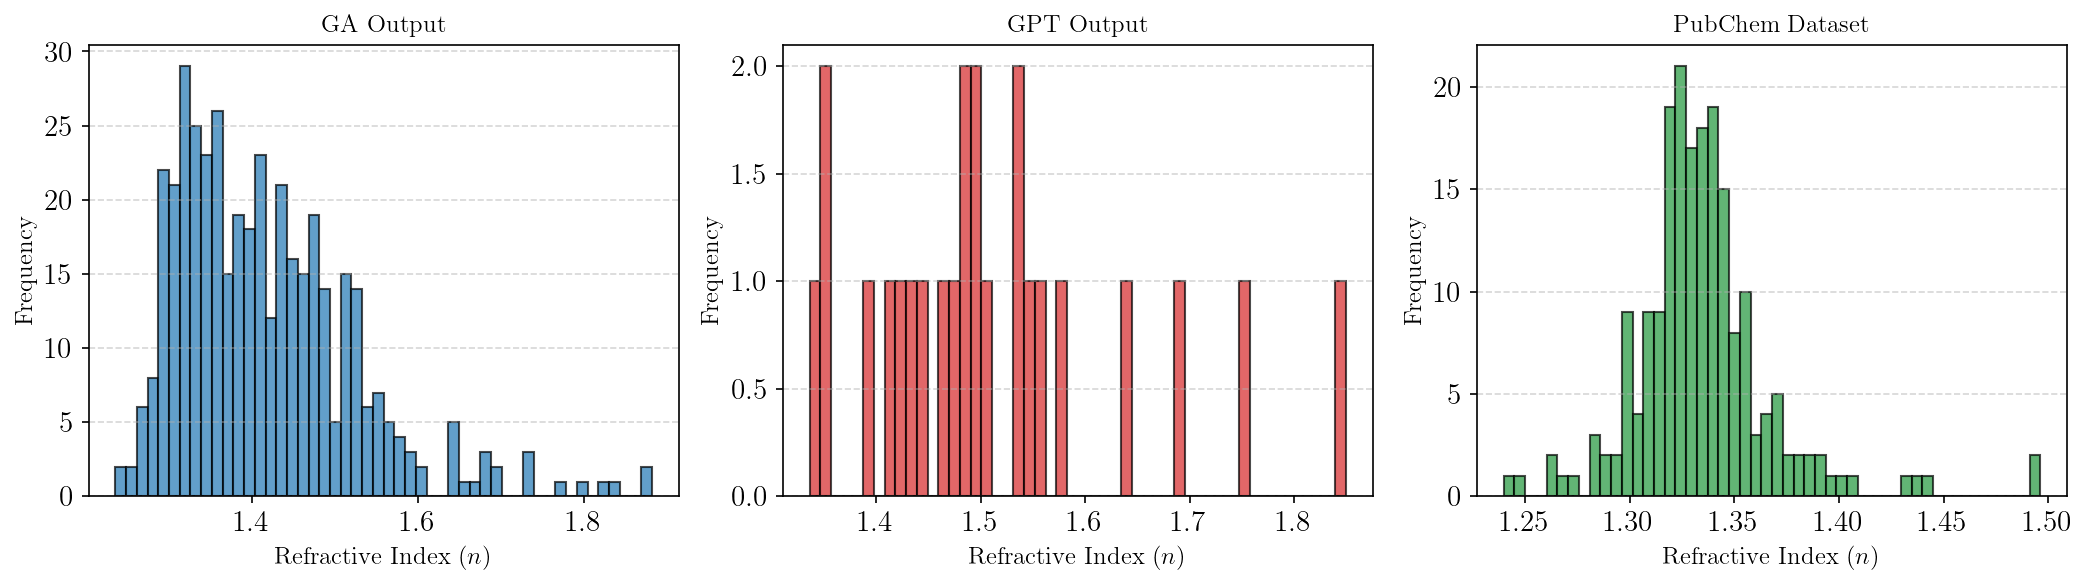

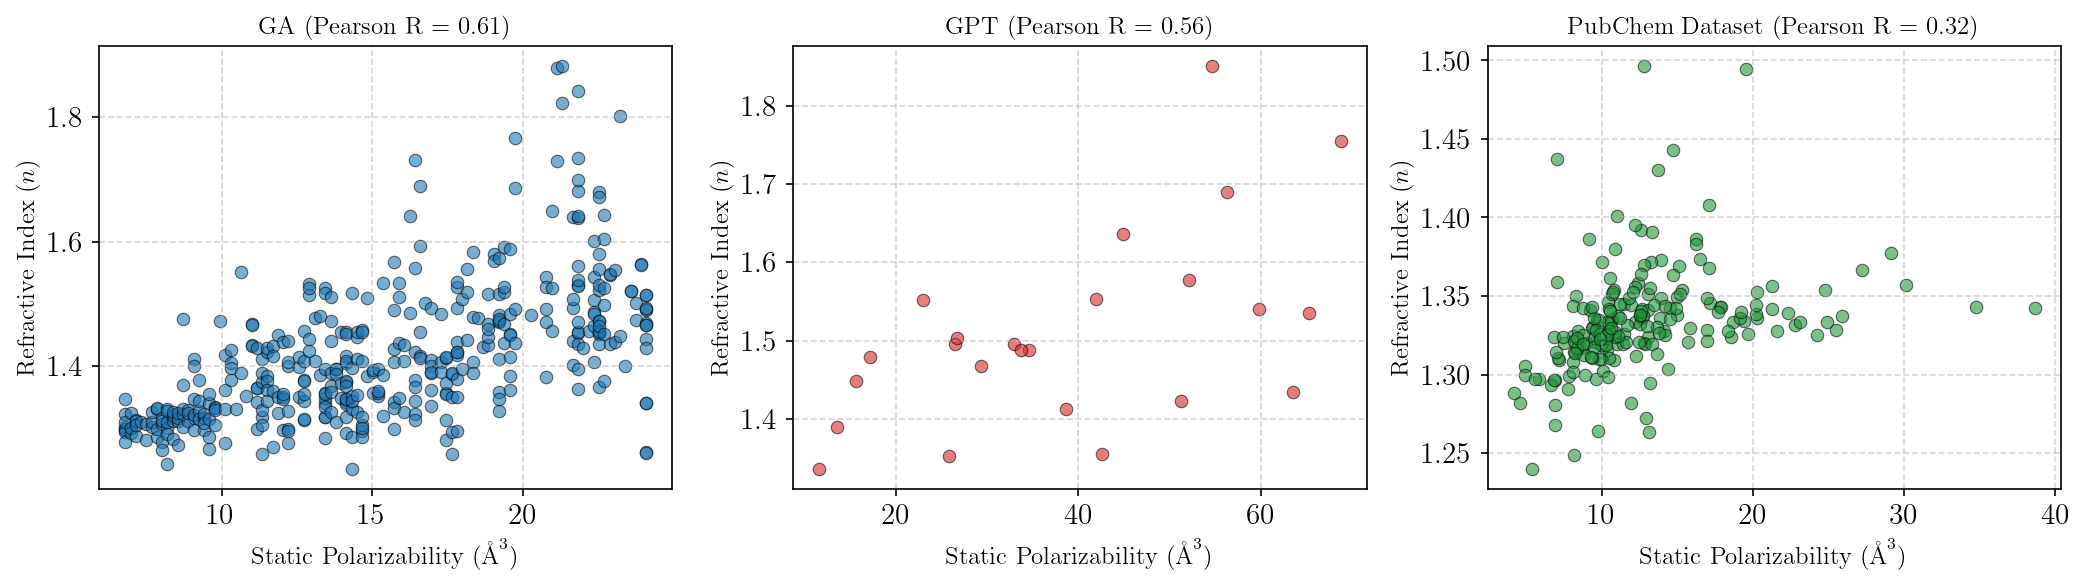

In [7]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import matplotlib as mpl

mpl.rcParams.update({
    "text.usetex": True,                # requires a LaTeX install
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.dpi": 150,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,                 # embed text as text in PDFs
})

# Define a consistent style/color scheme manually since we aren't using seaborn
GA_COLOR = '#1f77b4'  # Standard matplotlib blue
GPT_COLOR = '#d62728' # Standard matplotlib red
ORIGINAL_COLOR = "#20963a" # Standard matplotlib red
ALPHA_VAL = 0.6       # Transparency for scatter points

# ==========================================
# 1. Histograms (1x2 Grid)
# ==========================================
fig1, axes1 = plt.subplots(1, 3, figsize=(14, 4))

# --- GA Output Histogram ---
# Drop NaNs to avoid plotting errors
ga_ri = df_ga_output['refractive_index'].dropna()
axes1[0].hist(ga_ri, bins=50, color=GA_COLOR, alpha=0.7, edgecolor='black')
axes1[0].set_title('GA Output', fontsize=12)
axes1[0].set_xlabel(r'Refractive Index ($n$)', fontsize=12)
axes1[0].set_ylabel('Frequency', fontsize=12)
axes1[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- GPT Output Histogram ---
gpt_ri = df_gpt_output['refractive_index'].dropna()
axes1[1].hist(gpt_ri, bins=50, color=GPT_COLOR, alpha=0.7, edgecolor='black')
axes1[1].set_title('GPT Output', fontsize=12)
axes1[1].set_xlabel(r'Refractive Index ($n$)', fontsize=12)
axes1[1].set_ylabel('Frequency', fontsize=12)
axes1[1].grid(axis='y', linestyle='--', alpha=0.5)

# --- Original Output Histogram ---
original_ri = df_original['refractive_index'].dropna()
axes1[2].hist(original_ri, bins=50, color=ORIGINAL_COLOR, alpha=0.7, edgecolor='black')
axes1[2].set_title('PubChem Dataset', fontsize=12)
axes1[2].set_xlabel(r'Refractive Index ($n$)', fontsize=12)
axes1[2].set_ylabel('Frequency', fontsize=12)
axes1[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ==========================================
# 2. Scatter Plots with Correlation (1x2 Grid)
# ==========================================
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4))

def plot_scatter_mpl(df, x_col, y_col, ax, title, color):
    valid_data = df.dropna(subset=[x_col, y_col])
    x = valid_data[x_col] * 0.14818471
    y = valid_data[y_col]
    
    # Plot
    ax.scatter(x, y, alpha=ALPHA_VAL, c=color, edgecolor='k', linewidth=0.5)
    
    # Calculate Correlation
    if len(x) > 1:
        corr, _ = pearsonr(x, y)
    
    # Labels
    ax.set_title(title + f' (Pearson R = {corr:.2f})', fontsize=12)
    ax.set_xlabel(r'Static Polarizability ($\mathrm{\AA}^3$)', fontsize=12)
    ax.set_ylabel('Refractive Index ($n$)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)

# --- GA Scatter ---
plot_scatter_mpl(
    df_ga_output, 
    'static_polarizability_pred_original', 
    'refractive_index', 
    axes2[0], 
    'GA', 
    GA_COLOR
)

# --- GPT Scatter ---
plot_scatter_mpl(
    df_gpt_output, 
    'static_polarizability_pred_original', 
    'refractive_index', 
    axes2[1], 
    'GPT', 
    GPT_COLOR
)

# --- GPT Scatter ---
plot_scatter_mpl(
    df_original, 
    'static_polarizability', 
    'refractive_index', 
    axes2[2], 
    'PubChem Dataset', 
    ORIGINAL_COLOR
)

plt.tight_layout()
plt.show()

In [8]:
df_original[df_original['smiles'] == 'C=CC(=O)OCC(C(C(F)(F)F)(F)F)(F)F']

,polararea,mw,smiles,complexity,static_polarizability,vdw_volume,refractive_index


# t-SNE

In [9]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, GraphDescriptors

def get_rdkit_props(smiles):
    """
    Computes physical-chemical properties from a SMILES string using RDKit.
    Returns a pandas Series so it can be applied directly to a DataFrame.
    """
    mol = Chem.MolFromSmiles(smiles)
    
    # Handle invalid SMILES generated by models
    if mol is None:
        return pd.Series([None]*6, index=['polararea', 'mw', 'xlogp', 'complexity', 'heavycnt', 'rotbonds'])
    
    return pd.Series({
        'polararea': Descriptors.TPSA(mol),           # Topological Polar Surface Area
        'mw': Descriptors.MolWt(mol),                 # Molecular Weight
        'complexity': GraphDescriptors.BertzCT(mol),  # Bertz Complexity Index
    })

# --- Apply to GA Output ---
df_ga_output[['polararea', 'mw', 'complexity']] = \
    df_ga_output['smiles'].apply(get_rdkit_props)

# --- Apply to GPT Output ---
df_gpt_output[['polararea', 'mw', 'complexity']] = \
    df_gpt_output['smiles'].apply(get_rdkit_props)

[10:48:01] Conflicting single bond directions around double bond at index 5.
[10:48:01]   BondStereo set to STEREONONE and single bond directions set to NONE.
[10:48:01] Conflicting single bond directions around double bond at index 5.
[10:48:01]   BondStereo set to STEREONONE and single bond directions set to NONE.


In [10]:
df_original['static_polarizability'] = df_original['static_polarizability']*0.14818471 #A^3
df_ga_output['static_polarizability_pred_original'] = df_ga_output['static_polarizability_pred_original']*0.14818471
df_gpt_output['static_polarizability_pred_original'] = df_gpt_output['static_polarizability_pred_original']*0.14818471

In [11]:
df_original.columns

Index(['polararea', 'mw', 'smiles', 'complexity', 'static_polarizability',
       'vdw_volume', 'refractive_index'],
      dtype='object')

Running t-SNE on 3336 samples with features: ['mw', 'vdw_volume', 'static_polarizability', 'refractive_index']...


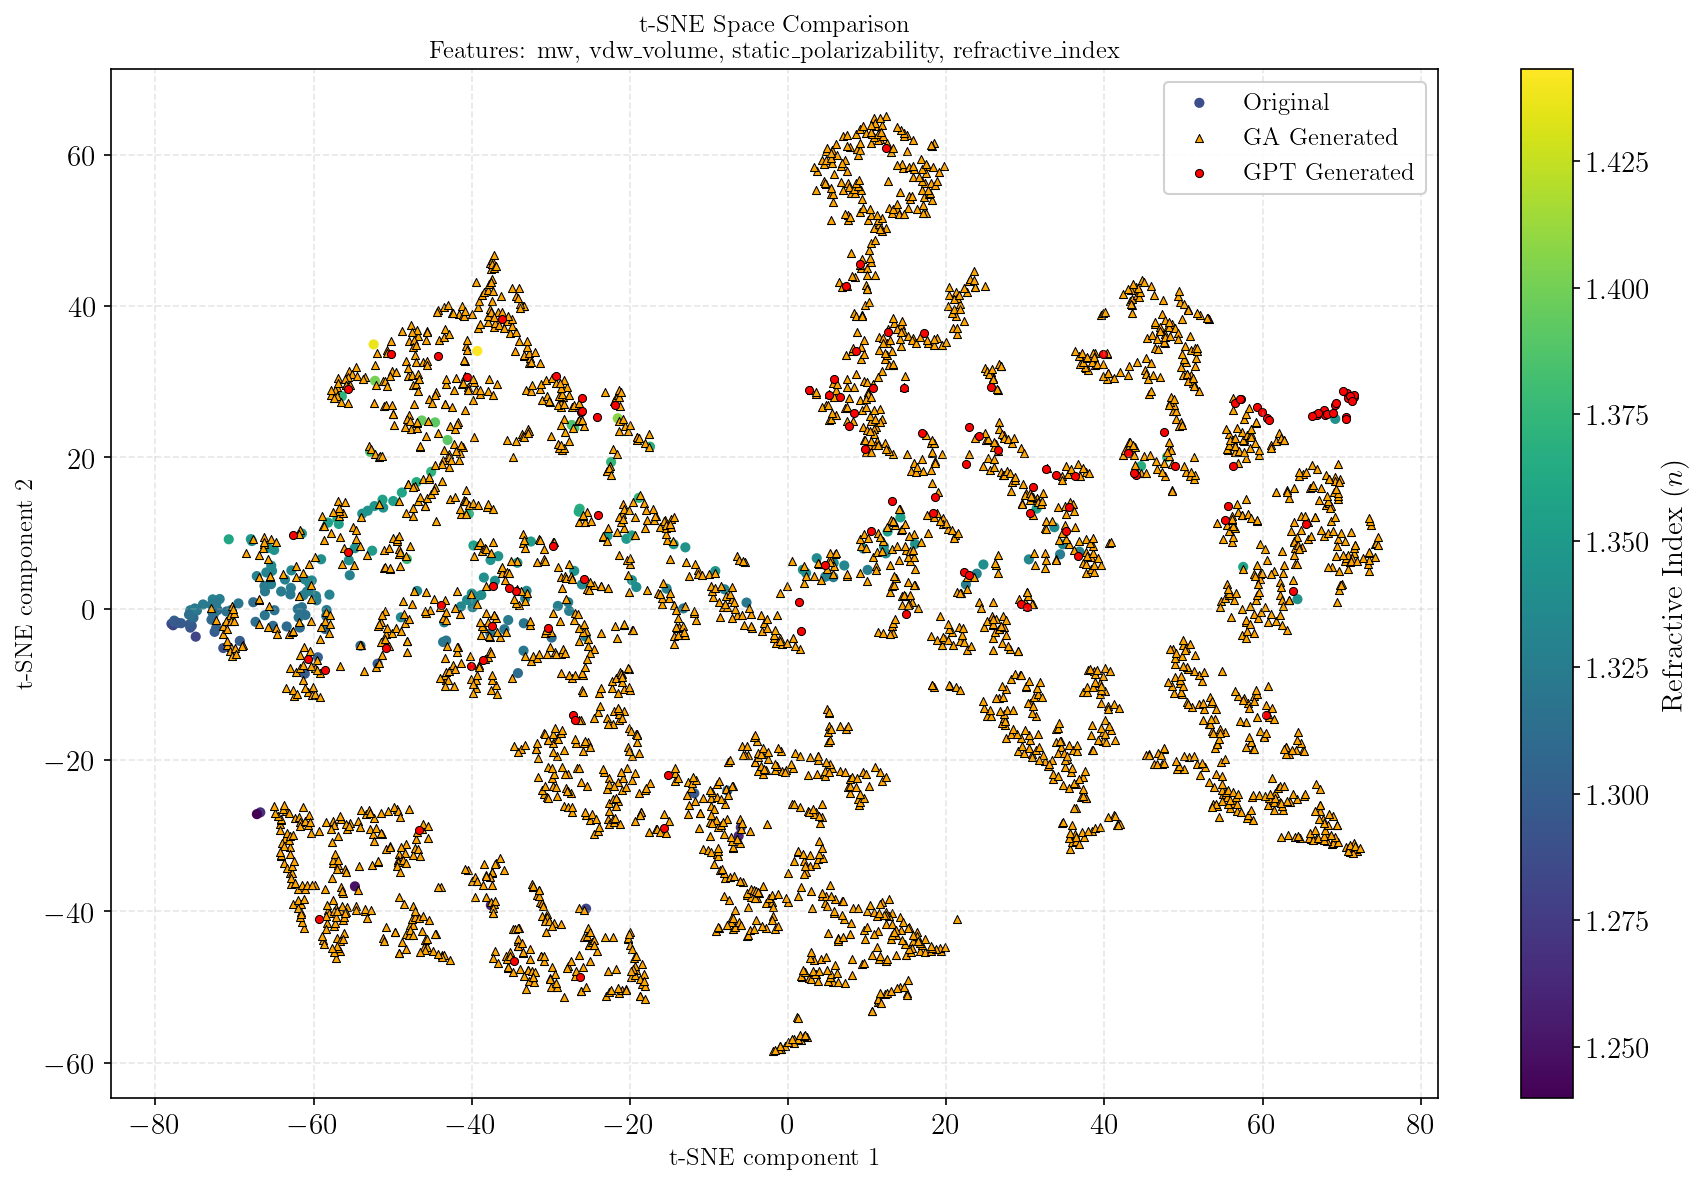

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. Prepare Data
# ==========================================

# Define the features we want to use for the embedding
feature_cols = ['mw', 'vdw_volume', 'static_polarizability', 'refractive_index']

# Helper to prepare a dataframe
def prepare_df(df, label, color):
    # Create a copy to avoid SettingWithCopy warnings
    temp = df.copy()
    
    # Handle column naming differences (GA/GPT often have 'pred' suffixes)
    if 'static_polarizability_pred_original' in temp.columns:
        temp = temp.rename(columns={'static_polarizability_pred_original': 'static_polarizability'})
    
    if 'vdw_volume' in temp.columns and 'vdw_volume' in feature_cols:
         pass # It's already there
    elif 'vdw_volume' not in temp.columns and 'vdw_volume' in feature_cols:
        # If missing in one, remove from feature list for fairness
        feature_cols.remove('vdw_volume')
        print(f"Note: 'vdw_volume' missing in {label}, excluding it from t-SNE.")

    # Select features and add metadata
    data = temp[feature_cols].copy()
    data['dataset'] = label
    data['color_code'] = color
    return data.dropna()

# Prepare the three datasets
try:
    df_ga_output = df_ga_output.drop(columns=['static_polarizability'])
    df_gpt_output = df_gpt_output.drop(columns=['static_polarizability'])
except:
    pass

df_orig_prep = prepare_df(df_original, 'Original', 'viridis') # Color placeholder
df_ga_prep   = prepare_df(df_ga_output, 'GA', 'red')
df_gpt_prep  = prepare_df(df_gpt_output, 'GPT', 'red') # Or 'orange' to distinguish

# Combine them
df_combined = pd.concat([df_orig_prep, df_ga_prep, df_gpt_prep], ignore_index=True)

# ==========================================
# 2. Run t-SNE on Combined Data
# ==========================================
print(f"Running t-SNE on {len(df_combined)} samples with features: {feature_cols}...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_combined[feature_cols])

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=2000)
X_embedded = tsne.fit_transform(X_scaled)

# Add coordinates back to dataframe
df_combined['tsne_1'] = X_embedded[:, 0]
df_combined['tsne_2'] = X_embedded[:, 1]

# ==========================================
# 3. Plotting
# ==========================================
plt.figure(figsize=(12, 8))

# --- Plot Original Data (Background) ---
mask_orig = df_combined['dataset'] == 'Original'
sc = plt.scatter(
    df_combined.loc[mask_orig, 'tsne_1'], 
    df_combined.loc[mask_orig, 'tsne_2'], 
    c=df_combined.loc[mask_orig, 'refractive_index'], 
    cmap='viridis', 
    #alpha=0.5, 
    s=15,
    label='Original'
)

# Add Colorbar for the original data
cbar = plt.colorbar(sc)
cbar.set_label(r'Refractive Index ($n$)', fontsize=14)

# --- Plot GA Data (Overlay in Red) ---
mask_ga = df_combined['dataset'] == 'GA'
plt.scatter(
    df_combined.loc[mask_ga, 'tsne_1'], 
    df_combined.loc[mask_ga, 'tsne_2'], 
    c='orange', 
    marker='^',   # Triangle marker to distinguish
    #alpha=0.8, 
    s=15,
    edgecolors='k',
    linewidth=0.5,
    label='GA Generated'
)

# --- Plot GPT Data (Overlay in Red/Magenta) ---
mask_gpt = df_combined['dataset'] == 'GPT'
plt.scatter(
    df_combined.loc[mask_gpt, 'tsne_1'], 
    df_combined.loc[mask_gpt, 'tsne_2'], 
    c='red',      # Or use 'magenta'/'orange' to separate GA vs GPT
    marker='o',   # Circle marker
    #alpha=0.8, 
    s=15,
    edgecolors='k',
    linewidth=0.5,
    label='GPT Generated'
)

# Formatting
plt.title(f't-SNE Space Comparison\nFeatures: {", ".join(feature_cols)}', fontsize=12)
plt.xlabel(r't-SNE component 1', fontsize=12)
plt.ylabel(r't-SNE component 2', fontsize=12)
plt.legend(loc='upper right', fontsize=12, frameon=True, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()